# Formula 1 Historical Data — Local Preprocessing & EDA (2010–2025)

Notebook ini **local-only** untuk dijalankan melalui Jupyter Notebook / JupyterLab / VS Code.

Tidak menggunakan:
- Google Colab mount
- Google Drive
- `/content`
- `google.colab`

## Struktur project yang disarankan

```text
F1_Tableau_Project/
├── data/
├── notebook/
│   ├── 01_kaggle_preprocessing_eda_local.ipynb
│   └── 02_fastf1_preprocessing_eda_local.ipynb
└── outputs/
```

Dataset Kaggle akan diunduh otomatis menggunakan `kagglehub` ke:

```text
data/kaggle/
```

Semua CSV hasil preprocessing akan disimpan ke:

```text
outputs/
```

Dataset yang digunakan:

`jtrotman/formula-1-race-data`

Periode analisis:

**2010–2025**

## 1. Install Dependencies

Jalankan cell ini sekali. Jika package sudah terpasang, pip hanya akan memastikan versinya tersedia.

In [1]:
%pip install -q -U "kagglehub>=1.0.2" pandas numpy matplotlib pyarrow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.66.0 requires numpy<2.5,>=1.22, but you have numpy 2.5.3 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Setup Project Directory

Notebook akan mencoba mendeteksi root project secara otomatis.

Jika Jupyter dijalankan dari folder `notebook/`, root dianggap satu tingkat di atasnya.

Jika Jupyter dijalankan dari root project, folder saat ini digunakan sebagai root.

In [2]:
from pathlib import Path
import re
import warnings
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd().resolve()

if cwd.name.lower() == "notebook":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

DATA_DIR = PROJECT_DIR / "data"
KAGGLE_DIR = DATA_DIR / "kaggle"
NOTEBOOK_DIR = PROJECT_DIR / "notebook"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for folder in [DATA_DIR, KAGGLE_DIR, NOTEBOOK_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

START_YEAR = 2010
END_YEAR = 2025

print("Current working directory :", cwd)
print("Project directory         :", PROJECT_DIR)
print("Kaggle data directory     :", KAGGLE_DIR)
print("Output directory          :", OUTPUT_DIR)

Current working directory : /home/user/projects/avd-uts/notebook
Project directory         : /home/user/projects/avd-uts
Kaggle data directory     : /home/user/projects/avd-uts/data/kaggle
Output directory          : /home/user/projects/avd-uts/outputs


## 3. Download Dataset via KaggleHub

Dataset akan diunduh langsung ke `data/kaggle/`.

Jika folder tersebut sudah memiliki dataset lengkap, download tidak dilakukan lagi.

In [3]:
import kagglehub

DATASET_HANDLE = "jtrotman/formula-1-race-data"

required_files = {
    "circuits.csv",
    "constructors.csv",
    "drivers.csv",
    "races.csv",
    "results.csv",
    "status.csv",
}

existing_names = {p.name for p in KAGGLE_DIR.rglob("*.csv")}

if required_files.issubset(existing_names):
    print("Dataset lengkap sudah tersedia. Download dilewati.")
else:
    print("Mengunduh dataset dari Kaggle...")
    downloaded_path = kagglehub.dataset_download(
        DATASET_HANDLE,
        output_dir=str(KAGGLE_DIR),
        force_download=True
    )
    print("Dataset path:", downloaded_path)

all_csvs = sorted(KAGGLE_DIR.rglob("*.csv"))

print(f"Total CSV ditemukan: {len(all_csvs)}")
for p in all_csvs:
    print("-", p.relative_to(KAGGLE_DIR))

Mengunduh dataset dari Kaggle...


100%|██████████| 8.97M/8.97M [00:01<00:00, 6.19MB/s]

Extracting files...


Dataset path: /home/user/projects/avd-uts/data/kaggle
Total CSV ditemukan: 14
- circuits.csv
- constructor_results.csv
- constructor_standings.csv
- constructors.csv
- driver_standings.csv
- drivers.csv
- lap_times.csv
- pit_stops.csv
- qualifying.csv
- races.csv
- results.csv
- seasons.csv
- sprint_results.csv
- status.csv


## 4. Validate Required Files

Cell ini mencegah error seperti:

```text
FileNotFoundError: circuits.csv ... tidak ditemukan
```

Notebook mencari file secara **recursive**, sehingga tetap bekerja jika KaggleHub membuat subfolder tambahan.

In [4]:
def find_file(filename: str):
    matches = list(KAGGLE_DIR.rglob(filename))
    return matches[0] if matches else None

missing_required = [
    filename for filename in sorted(required_files)
    if find_file(filename) is None
]

if missing_required:
    print("Isi KAGGLE_DIR saat ini:")
    for p in sorted(KAGGLE_DIR.rglob("*")):
        if p.is_file():
            print("-", p.relative_to(KAGGLE_DIR))
    raise FileNotFoundError(
        "File wajib tidak ditemukan setelah download: "
        f"{missing_required}"
    )

print("Semua file wajib ditemukan:")
for filename in sorted(required_files):
    print(f"- {filename}: {find_file(filename)}")

Semua file wajib ditemukan:
- circuits.csv: /home/user/projects/avd-uts/data/kaggle/circuits.csv
- constructors.csv: /home/user/projects/avd-uts/data/kaggle/constructors.csv
- drivers.csv: /home/user/projects/avd-uts/data/kaggle/drivers.csv
- races.csv: /home/user/projects/avd-uts/data/kaggle/races.csv
- results.csv: /home/user/projects/avd-uts/data/kaggle/results.csv
- status.csv: /home/user/projects/avd-uts/data/kaggle/status.csv


## 5. Load & Inspect Raw Tables

In [5]:
OPTIONAL_FILES = [
    "qualifying.csv",
    "pit_stops.csv",
    "lap_times.csv",
    "driver_standings.csv",
    "constructor_standings.csv",
    "constructor_results.csv",
    "sprint_results.csv",
]

def read_f1_csv(path: Path):
    return pd.read_csv(
        path,
        na_values=["\\N", "NA", "N/A", "null", ""]
    )

tables = {}

for filename in list(sorted(required_files)) + OPTIONAL_FILES:
    path = find_file(filename)
    if path is not None:
        tables[filename] = read_f1_csv(path)

inventory = []

for filename, df in tables.items():
    inventory.append({
        "file": filename,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "missing_pct": round(df.isna().mean().mean() * 100, 2),
    })

inventory = (
    pd.DataFrame(inventory)
    .sort_values("file")
    .reset_index(drop=True)
)

display(inventory)

,file,rows,columns,duplicate_rows,missing_cells,missing_pct
0,circuits.csv,78,9,0,0,0.00
1,constructor_results.csv,13019,5,0,13002,19.97
2,constructor_standings.csv,13785,7,0,1,0.00
3,constructors.csv,214,5,0,0,0.00
4,driver_standings.csv,35672,7,0,13,0.01
5,drivers.csv,865,9,0,1559,20.03
6,lap_times.csv,882027,6,1707,0,0.00
7,pit_stops.csv,22668,7,0,6,0.00
8,qualifying.csv,11276,9,0,12291,12.11
9,races.csv,1172,18,0,11479,54.41


In [6]:
for filename, df in tables.items():
    print("=" * 100)
    print(filename, df.shape)
    print("Columns:", list(df.columns))
    display(df.head(3))

circuits.csv (78, 9)
Columns: ['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...


constructors.csv (214, 5)
Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...


drivers.csv (865, 9)
Columns: ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']


...

,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1.0,1,1
1,2,18,2,8.0,3.0,3,0
2,3,18,3,9.0,2.0,2,0


constructor_results.csv (13019, 5)
Columns: ['constructorResultsId', 'raceId', 'constructorId', 'points', 'status']


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN


sprint_results.csv (590, 17)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'fastestLapTime', 'statusId', 'rank']


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId,rank
0,1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1.0,NaN
1,2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1.0,NaN
2,3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1.0,NaN


## 6. Clean Core Tables

In [7]:
def to_numeric_if_present(df, columns):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

races = to_numeric_if_present(
    tables["races.csv"],
    ["raceId", "year", "round", "circuitId"]
)

results = to_numeric_if_present(
    tables["results.csv"],
    [
        "resultId", "raceId", "driverId", "constructorId",
        "grid", "position", "positionOrder", "points", "laps",
        "milliseconds", "fastestLap", "rank",
        "fastestLapSpeed", "statusId"
    ]
)

drivers = to_numeric_if_present(
    tables["drivers.csv"],
    ["driverId", "number"]
)

constructors = to_numeric_if_present(
    tables["constructors.csv"],
    ["constructorId"]
)

circuits = to_numeric_if_present(
    tables["circuits.csv"],
    ["circuitId", "lat", "lng", "alt"]
)

status = to_numeric_if_present(
    tables["status.csv"],
    ["statusId"]
)

if "date" in races.columns:
    races["date"] = pd.to_datetime(races["date"], errors="coerce")

print("Raw season range:", races["year"].min(), "-", races["year"].max())

Raw season range: 1950 - 2026


## 7. Filter 2010–2025

In [8]:
races_period = races.loc[
    races["year"].between(START_YEAR, END_YEAR)
].copy()

race_ids_period = set(
    races_period["raceId"].dropna().astype(int)
)

print("Selected season range:",
      races_period["year"].min(),
      "-",
      races_period["year"].max())

print("Races:", len(races_period))

assert races_period["year"].min() >= START_YEAR
assert races_period["year"].max() <= END_YEAR

Selected season range: 2010 - 2025
Races: 329


## 8. Build Race-Level Analytical Dataset

**Grain:** satu baris = satu driver pada satu race.

In [9]:
races_dim = races_period.rename(columns={
    "name": "race_name",
    "date": "race_date",
    "time": "race_start_time",
    "url": "race_url",
})

drivers_dim = drivers.rename(columns={
    "number": "driver_number",
    "code": "driver_code",
    "nationality": "driver_nationality",
    "url": "driver_url",
})

drivers_dim["driver_name"] = (
    drivers_dim["forename"].fillna("").astype(str).str.strip()
    + " " +
    drivers_dim["surname"].fillna("").astype(str).str.strip()
).str.strip()

constructors_dim = constructors.rename(columns={
    "name": "constructor_name",
    "nationality": "constructor_nationality",
    "url": "constructor_url",
})

circuits_dim = circuits.rename(columns={
    "name": "circuit_name",
    "location": "circuit_location",
    "country": "circuit_country",
    "url": "circuit_url",
})

status_dim = status.rename(columns={
    "status": "status_description"
})

In [10]:
race_results = (
    results.loc[results["raceId"].isin(race_ids_period)]
    .merge(
        races_dim[
            ["raceId", "year", "round", "circuitId",
             "race_name", "race_date"]
        ],
        on="raceId",
        how="left",
        validate="many_to_one"
    )
    .merge(
        drivers_dim[
            ["driverId", "driver_name", "driver_code",
             "driver_number", "driver_nationality"]
        ],
        on="driverId",
        how="left",
        validate="many_to_one"
    )
    .merge(
        constructors_dim[
            ["constructorId", "constructor_name",
             "constructor_nationality"]
        ],
        on="constructorId",
        how="left",
        validate="many_to_one"
    )
    .merge(
        circuits_dim[
            ["circuitId", "circuit_name", "circuit_location",
             "circuit_country", "lat", "lng", "alt"]
        ],
        on="circuitId",
        how="left",
        validate="many_to_one"
    )
    .merge(
        status_dim[
            ["statusId", "status_description"]
        ],
        on="statusId",
        how="left",
        validate="many_to_one"
    )
)

race_results.rename(columns={
    "year": "season",
    "position": "official_position",
    "positionOrder": "finish_position_order",
}, inplace=True)

print("Race-level shape:", race_results.shape)
display(race_results.head())

Race-level shape: (6915, 36)


,resultId,raceId,driverId,constructorId,number,grid,official_position,positionText,finish_position_order,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,season,round,circuitId,race_name,race_date,driver_name,driver_code,driver_number,driver_nationality,constructor_name,constructor_nationality,circuit_name,circuit_location,circuit_country,lat,lng,alt,status_description
0,20323,337,4,6,8.0,3.0,1.0,1,1,25.0,49,1:39:20.396,5960396.0,45.0,1.0,1:58.287,191.706,1,2010,1,3,Bahrain Grand Prix,2010-03-14,Fernando Alonso,ALO,14.0,Spanish,Ferrari,Italian,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.5106,7,Finished
1,20324,337,13,6,7.0,2.0,2.0,2,2,18.0,49,+16.099,5976495.0,38.0,5.0,1:59.732,189.392,1,2010,1,3,Bahrain Grand Prix,2010-03-14,Felipe Massa,MAS,19.0,Brazilian,Ferrari,Italian,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.5106,7,Finished
2,20325,337,1,1,2.0,4.0,3.0,3,3,15.0,49,+23.182,5983578.0,42.0,4.0,1:59.560,189.665,1,2010,1,3,Bahrain Grand Prix,2010-03-14,Lewis Hamilton,HAM,44.0,British,McLaren,British,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.5106,7,Finished
3,20326,337,20,9,5.0,1.0,4.0,4,4,12.0,49,+38.799,5999195.0,32.0,12.0,2:00.218,188.627,1,2010,1,3,Bahrain Grand Prix,2010-03-14,Sebastian Vettel,VET,5.0,German,Red Bull,Austrian,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.5106,7,Finished
4,20327,337,3,131,4.0,5.0,5.0,5,5,10.0,49,+40.213,6000609.0,45.0,13.0,2:00.236,188.599,1,2010,1,3,Bahrain Grand Prix,2010-03-14,Nico Rosberg,ROS,6.0,German,Mercedes,German,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.5106,7,Finished


## 9. Feature Engineering

### Position Gain

\[
PositionGain = Grid - FinishPosition
\]

`grid = 0` tidak dianggap posisi start normal.

### Reliability

Notebook memisahkan empat ukuran:

1. **Paper Reliability Score**
   - cumulative points / cumulative points tertinggi
   - mengikuti implementasi paper.

2. **Finish Rate**
   - proporsi classified finish.

3. **DNF Rate**
   - proporsi non-classified finish.

4. **Mechanical DNF Rate**
   - proporsi DNF yang dikategorikan mechanical/technical.

In [11]:
race_results["grid"] = pd.to_numeric(
    race_results["grid"],
    errors="coerce"
)

race_results["finish_position_order"] = pd.to_numeric(
    race_results["finish_position_order"],
    errors="coerce"
)

race_results["valid_grid_flag"] = (
    race_results["grid"].gt(0).astype(int)
)

race_results["position_gain"] = np.where(
    race_results["grid"].gt(0)
    & race_results["finish_position_order"].notna(),
    race_results["grid"] - race_results["finish_position_order"],
    np.nan
)

race_results["win_flag"] = (
    race_results["finish_position_order"].eq(1).astype(int)
)

race_results["podium_flag"] = (
    race_results["finish_position_order"].le(3).astype(int)
)

status_lower = (
    race_results["status_description"]
    .fillna("Unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

race_results["finished_flag"] = (
    status_lower.eq("finished")
    | status_lower.str.match(r"^\+\d+\s+lap")
).astype(int)

race_results["dnf_flag"] = (
    1 - race_results["finished_flag"]
).astype(int)

In [12]:
MECHANICAL_KEYWORDS = [
    "engine", "gearbox", "transmission", "clutch",
    "hydraulic", "electrical", "electronics",
    "radiator", "suspension", "brake",
    "differential", "overheating", "mechanical",
    "tyre", "tire", "puncture", "wheel",
    "driveshaft", "power unit", "ers", "turbo",
    "fuel", "oil", "exhaust", "water leak",
    "battery", "throttle", "steering", "technical"
]

ACCIDENT_KEYWORDS = [
    "accident", "collision", "spun", "crash", "damage"
]

DSQ_KEYWORDS = [
    "disqualified", "excluded"
]

def categorize_status(status_text):
    s = str(status_text).lower().strip()

    if s == "finished" or re.match(r"^\+\d+\s+lap", s):
        return "Finished"

    if any(keyword in s for keyword in DSQ_KEYWORDS):
        return "Disqualified"

    if any(keyword in s for keyword in ACCIDENT_KEYWORDS):
        return "Accident/Collision"

    if any(keyword in s for keyword in MECHANICAL_KEYWORDS):
        return "Mechanical/Technical"

    return "Other DNF"

race_results["dnf_category"] = (
    race_results["status_description"]
    .apply(categorize_status)
)

race_results["mechanical_dnf_flag"] = (
    race_results["dnf_category"]
    .eq("Mechanical/Technical")
    .astype(int)
)

status_audit = (
    race_results[
        [
            "status_description",
            "finished_flag",
            "dnf_flag",
            "dnf_category",
            "mechanical_dnf_flag"
        ]
    ]
    .drop_duplicates()
    .sort_values(["dnf_category", "status_description"])
)

display(status_audit)

,status_description,finished_flag,dnf_flag,dnf_category,mechanical_dnf_flag
23,Accident,0,1,Accident/Collision,0
44,Collision,0,1,Accident/Collision,0
1290,Collision damage,0,1,Accident/Collision,0
3895,Damage,0,1,Accident/Collision,0
42,Spun off,0,1,Accident/Collision,0
476,Disqualified,0,1,Disqualified,0
2571,Excluded,0,1,Disqualified,0
13,+1 Lap,1,0,Finished,0
65,+10 Laps,1,0,Finished,0
1172,+11 Laps,1,0,Finished,0


## 10. Driver Summary

In [13]:
driver_summary = (
    race_results.groupby(
        ["driverId", "driver_name"],
        dropna=False
    )
    .agg(
        starts=("raceId", "nunique"),
        seasons=("season", "nunique"),
        first_season=("season", "min"),
        last_season=("season", "max"),
        wins=("win_flag", "sum"),
        podiums=("podium_flag", "sum"),
        cumulative_points=("points", "sum"),
        avg_points_per_start=("points", "mean"),
        avg_grid=("grid", lambda x: x[x > 0].mean()),
        avg_finish=("finish_position_order", "mean"),
        avg_position_gain=("position_gain", "mean"),
        finishes=("finished_flag", "sum"),
        dnfs=("dnf_flag", "sum"),
        mechanical_dnfs=("mechanical_dnf_flag", "sum"),
    )
    .reset_index()
)

driver_summary["finish_rate"] = (
    driver_summary["finishes"]
    / driver_summary["starts"].replace(0, np.nan)
)

driver_summary["dnf_rate"] = (
    driver_summary["dnfs"]
    / driver_summary["starts"].replace(0, np.nan)
)

driver_summary["mechanical_dnf_rate"] = (
    driver_summary["mechanical_dnfs"]
    / driver_summary["starts"].replace(0, np.nan)
)

driver_summary["paper_reliability_score"] = (
    driver_summary["cumulative_points"]
    / driver_summary["cumulative_points"].max()
)

display(
    driver_summary
    .sort_values("cumulative_points", ascending=False)
    .head(15)
)

,driverId,driver_name,starts,seasons,first_season,last_season,wins,podiums,cumulative_points,avg_points_per_start,avg_grid,avg_finish,avg_position_gain,finishes,dnfs,mechanical_dnfs,finish_rate,dnf_rate,mechanical_dnf_rate,paper_reliability_score
0,1,Lewis Hamilton,328,16,2010,2025,94,175,4699.5,14.327744,4.506135,5.076220,-0.536810,297,31,15,0.905488,0.094512,0.045732,1.000000
47,830,Max Verstappen,233,11,2015,2025,71,127,3301.5,14.169528,4.844156,5.442060,-0.562771,200,33,18,0.858369,0.141631,0.077253,0.702522
13,20,Sebastian Vettel,257,13,2010,2022,48,113,2973.0,11.568093,5.850980,6.540856,-0.615686,225,32,16,0.875486,0.124514,0.062257,0.632620
3,4,Fernando Alonso,288,14,2010,2025,11,53,1803.0,6.260417,9.192308,9.309028,-0.101399,234,54,35,0.812500,0.187500,0.121528,0.383658
39,822,Valtteri Bottas,247,12,2013,2024,10,67,1788.0,7.238866,7.991770,8.967611,-0.905350,217,30,18,0.878543,0.121457,0.072874,0.380466
61,844,Charles Leclerc,173,8,2018,2025,8,50,1588.0,9.179191,6.315789,7.445087,-1.052632,146,27,10,0.843931,0.156069,0.057803,0.337908
32,815,Sergio Pérez,283,14,2011,2024,6,39,1585.0,5.600707,9.751825,9.332155,0.529197,242,41,17,0.855124,0.144876,0.060071,0.337270
2,3,Nico Rosberg,136,7,2010,2016,23,55,1519.0,11.169118,4.860294,6.683824,-1.823529,121,15,8,0.889706,0.110294,0.058824,0.323226
63,846,Lando Norris,152,7,2019,2025,11,44,1344.0,8.842105,6.609272,7.282895,-0.695364,138,14,5,0.907895,0.092105,0.032895,0.285988
34,817,Daniel Ricciardo,257,14,2011,2024,8,32,1320.0,5.136187,9.988281,10.206226,-0.191406,217,40,28,0.844358,0.155642,0.108949,0.280881


## 11. Constructor Summary

In [14]:
constructor_summary = (
    race_results.groupby(
        ["constructorId", "constructor_name"],
        dropna=False
    )
    .agg(
        car_starts=("resultId", "size"),
        races=("raceId", "nunique"),
        seasons=("season", "nunique"),
        first_season=("season", "min"),
        last_season=("season", "max"),
        wins=("win_flag", "sum"),
        podiums=("podium_flag", "sum"),
        cumulative_points=("points", "sum"),
        avg_grid=("grid", lambda x: x[x > 0].mean()),
        avg_finish=("finish_position_order", "mean"),
        avg_position_gain=("position_gain", "mean"),
        finishes=("finished_flag", "sum"),
        dnfs=("dnf_flag", "sum"),
        mechanical_dnfs=("mechanical_dnf_flag", "sum"),
    )
    .reset_index()
)

constructor_summary["finish_rate"] = (
    constructor_summary["finishes"]
    / constructor_summary["car_starts"].replace(0, np.nan)
)

constructor_summary["dnf_rate"] = (
    constructor_summary["dnfs"]
    / constructor_summary["car_starts"].replace(0, np.nan)
)

constructor_summary["mechanical_dnf_rate"] = (
    constructor_summary["mechanical_dnfs"]
    / constructor_summary["car_starts"].replace(0, np.nan)
)

constructor_summary["paper_reliability_score"] = (
    constructor_summary["cumulative_points"]
    / constructor_summary["cumulative_points"].max()
)

display(
    constructor_summary
    .sort_values("cumulative_points", ascending=False)
    .head(15)
)

,constructorId,constructor_name,car_starts,races,seasons,first_season,last_season,wins,podiums,cumulative_points,avg_grid,avg_finish,avg_position_gain,finishes,dnfs,mechanical_dnfs,finish_rate,dnf_rate,mechanical_dnf_rate,paper_reliability_score
10,131,Mercedes,658,329,16,2010,2025,122,293,8015.5,5.117737,6.003040,-0.870031,592,66,35,0.899696,0.100304,0.053191,1.000000
5,9,Red Bull,658,329,16,2010,2025,124,278,7826.5,5.610853,6.308511,-0.595349,568,90,49,0.863222,0.136778,0.074468,0.976421
4,6,Ferrari,658,329,16,2010,2025,38,208,6454.5,6.044410,6.846505,-0.738132,575,83,31,0.873860,0.126140,0.047112,0.805252
0,1,McLaren,658,329,16,2010,2025,39,122,4248.0,8.923780,9.279635,-0.375000,548,110,66,0.832827,0.167173,0.100304,0.529973
1,3,Williams,657,329,16,2010,2025,1,19,1159.0,13.242613,13.296804,-0.001555,528,129,60,0.803653,0.196347,0.091324,0.144595
6,10,Force India,354,177,9,2010,2018,0,5,1085.0,11.073446,10.940678,0.132768,292,62,22,0.824859,0.175141,0.062147,0.135363
16,208,Lotus F1,154,77,4,2012,2015,2,25,706.0,10.818182,11.311688,-0.493506,112,42,21,0.727273,0.272727,0.136364,0.088079
2,4,Renault,276,138,7,2010,2020,0,8,695.0,11.712727,12.144928,-0.429091,211,65,36,0.764493,0.235507,0.130435,0.086707
9,117,Aston Martin,227,114,5,2021,2025,0,9,572.0,11.912844,11.488987,0.527523,194,33,11,0.854626,0.145374,0.048458,0.071362
21,214,Alpine F1 Team,228,114,5,2021,2025,1,6,518.0,12.058824,12.092105,0.054299,193,35,17,0.846491,0.153509,0.074561,0.064625


## 12. Driver–Constructor–Season Summary

In [15]:
driver_constructor_summary = (
    race_results.groupby(
        [
            "season",
            "driverId",
            "driver_name",
            "constructorId",
            "constructor_name"
        ],
        dropna=False
    )
    .agg(
        starts=("raceId", "nunique"),
        wins=("win_flag", "sum"),
        podiums=("podium_flag", "sum"),
        points=("points", "sum"),
        avg_grid=("grid", lambda x: x[x > 0].mean()),
        avg_finish=("finish_position_order", "mean"),
        avg_position_gain=("position_gain", "mean"),
        finishes=("finished_flag", "sum"),
        dnfs=("dnf_flag", "sum"),
        mechanical_dnfs=("mechanical_dnf_flag", "sum"),
    )
    .reset_index()
)

driver_constructor_summary["finish_rate"] = (
    driver_constructor_summary["finishes"]
    / driver_constructor_summary["starts"].replace(0, np.nan)
)

driver_constructor_summary["dnf_rate"] = (
    driver_constructor_summary["dnfs"]
    / driver_constructor_summary["starts"].replace(0, np.nan)
)

driver_constructor_summary["mechanical_dnf_rate"] = (
    driver_constructor_summary["mechanical_dnfs"]
    / driver_constructor_summary["starts"].replace(0, np.nan)
)

display(driver_constructor_summary.head())

,season,driverId,driver_name,constructorId,constructor_name,starts,wins,podiums,points,avg_grid,avg_finish,avg_position_gain,finishes,dnfs,mechanical_dnfs,finish_rate,dnf_rate,mechanical_dnf_rate
0,2010,1,Lewis Hamilton,1,McLaren,19,3,9,240.0,5.157895,6.421053,-1.263158,15,4,2,0.789474,0.210526,0.105263
1,2010,2,Nick Heidfeld,15,Sauber,5,0,0,6.0,13.400000,12.600000,0.800000,4,1,0,0.800000,0.200000,0.000000
2,2010,3,Nico Rosberg,131,Mercedes,19,0,3,142.0,7.368421,8.263158,-0.894737,16,3,2,0.842105,0.157895,0.105263
3,2010,4,Fernando Alonso,6,Ferrari,19,5,10,252.0,5.789474,5.421053,0.368421,17,2,1,0.894737,0.105263,0.052632
4,2010,5,Heikki Kovalainen,205,Lotus,19,0,0,0.0,18.894737,17.000000,1.894737,13,6,4,0.684211,0.315789,0.210526


## 13. Combined Reliability Summary

In [16]:
driver_rel = driver_summary[
    [
        "driver_name",
        "starts",
        "cumulative_points",
        "paper_reliability_score",
        "finish_rate",
        "dnf_rate",
        "mechanical_dnf_rate"
    ]
].copy()

driver_rel.insert(0, "entity_type", "Driver")
driver_rel.rename(
    columns={"driver_name": "entity_name"},
    inplace=True
)

constructor_rel = constructor_summary[
    [
        "constructor_name",
        "car_starts",
        "cumulative_points",
        "paper_reliability_score",
        "finish_rate",
        "dnf_rate",
        "mechanical_dnf_rate"
    ]
].copy()

constructor_rel.rename(
    columns={
        "constructor_name": "entity_name",
        "car_starts": "starts"
    },
    inplace=True
)

constructor_rel.insert(0, "entity_type", "Constructor")

reliability_summary = pd.concat(
    [driver_rel, constructor_rel],
    ignore_index=True
)

display(reliability_summary.head())

,entity_type,entity_name,starts,cumulative_points,paper_reliability_score,finish_rate,dnf_rate,mechanical_dnf_rate
0,Driver,Lewis Hamilton,328,4699.5,1.000000,0.905488,0.094512,0.045732
1,Driver,Nick Heidfeld,16,40.0,0.008512,0.750000,0.250000,0.000000
2,Driver,Nico Rosberg,136,1519.0,0.323226,0.889706,0.110294,0.058824
3,Driver,Fernando Alonso,288,1803.0,0.383658,0.812500,0.187500,0.121528
4,Driver,Heikki Kovalainen,60,0.0,0.000000,0.800000,0.200000,0.150000


## 14. Optional Fact Tables

Lap times, pit stops, dan qualifying **tidak** di-join langsung ke race-level table karena grain berbeda.

In [17]:
race_lookup = races_dim[
    [
        "raceId",
        "year",
        "round",
        "circuitId",
        "race_name",
        "race_date"
    ]
].rename(columns={"year": "season"})

driver_lookup = drivers_dim[
    [
        "driverId",
        "driver_name",
        "driver_code",
        "driver_number"
    ]
]

constructor_lookup = constructors_dim[
    [
        "constructorId",
        "constructor_name"
    ]
]

qualifying_clean = None
pit_stops_clean = None
lap_times_clean = None

if "qualifying.csv" in tables:
    qualifying = to_numeric_if_present(
        tables["qualifying.csv"],
        [
            "qualifyId", "raceId", "driverId",
            "constructorId", "number", "position"
        ]
    )

    qualifying_clean = (
        qualifying.loc[
            qualifying["raceId"].isin(race_ids_period)
        ]
        .merge(
            race_lookup,
            on="raceId",
            how="left",
            validate="many_to_one"
        )
        .merge(
            driver_lookup,
            on="driverId",
            how="left",
            validate="many_to_one"
        )
        .merge(
            constructor_lookup,
            on="constructorId",
            how="left",
            validate="many_to_one"
        )
    )

if "pit_stops.csv" in tables:
    pit = to_numeric_if_present(
        tables["pit_stops.csv"],
        ["raceId", "driverId", "stop", "lap", "milliseconds"]
    )

    pit_stops_clean = (
        pit.loc[
            pit["raceId"].isin(race_ids_period)
        ]
        .merge(
            race_lookup,
            on="raceId",
            how="left",
            validate="many_to_one"
        )
        .merge(
            driver_lookup,
            on="driverId",
            how="left",
            validate="many_to_one"
        )
    )

    if "milliseconds" in pit_stops_clean.columns:
        pit_stops_clean["pit_duration_seconds"] = (
            pit_stops_clean["milliseconds"] / 1000
        )

if "lap_times.csv" in tables:
    laps = to_numeric_if_present(
        tables["lap_times.csv"],
        ["raceId", "driverId", "lap", "position", "milliseconds"]
    )

    lap_times_clean = (
        laps.loc[
            laps["raceId"].isin(race_ids_period)
        ]
        .merge(
            race_lookup,
            on="raceId",
            how="left",
            validate="many_to_one"
        )
        .merge(
            driver_lookup,
            on="driverId",
            how="left",
            validate="many_to_one"
        )
    )

    if "milliseconds" in lap_times_clean.columns:
        lap_times_clean["lap_time_seconds"] = (
            lap_times_clean["milliseconds"] / 1000
        )

print(
    "Qualifying:",
    None if qualifying_clean is None else qualifying_clean.shape
)
print(
    "Pit stops:",
    None if pit_stops_clean is None else pit_stops_clean.shape
)
print(
    "Lap times:",
    None if lap_times_clean is None else lap_times_clean.shape
)

Qualifying: (6891, 18)
Pit stops: (12784, 16)
Lap times: (369465, 15)


## 15. EDA — Data Coverage

,season,races,drivers,constructors,circuits
0,2010,19,27,12,19
1,2011,19,28,12,19
2,2012,20,25,12,20
3,2013,19,23,11,19
4,2014,19,24,11,19
5,2015,19,22,10,19
6,2016,21,24,11,21
7,2017,20,25,10,20
8,2018,21,20,10,21
9,2019,21,20,10,21


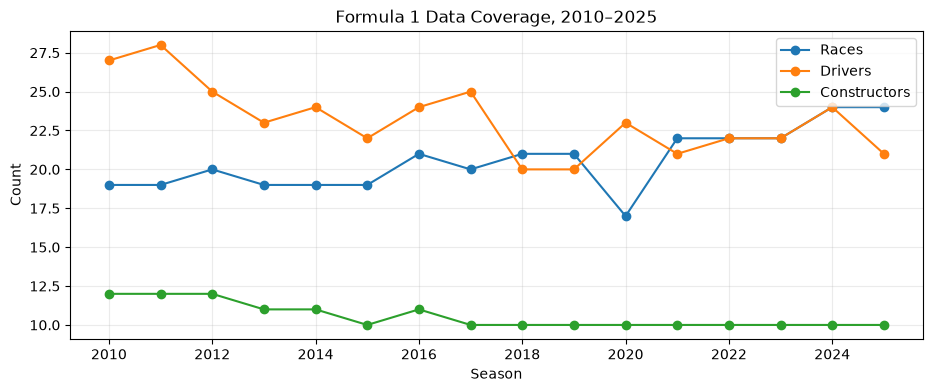

In [18]:
coverage = (
    race_results.groupby("season")
    .agg(
        races=("raceId", "nunique"),
        drivers=("driverId", "nunique"),
        constructors=("constructorId", "nunique"),
        circuits=("circuitId", "nunique")
    )
    .reset_index()
)

display(coverage)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(coverage["season"], coverage["races"], marker="o", label="Races")
ax.plot(coverage["season"], coverage["drivers"], marker="o", label="Drivers")
ax.plot(
    coverage["season"],
    coverage["constructors"],
    marker="o",
    label="Constructors"
)
ax.set_title("Formula 1 Data Coverage, 2010–2025")
ax.set_xlabel("Season")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 16. EDA — Grid Position vs Average Points

,grid,avg_points,avg_finish,observations
0,1.0,18.870427,3.487805,328
1,2.0,15.696319,4.404908,326
2,3.0,12.580793,5.350610,328
3,4.0,10.920732,6.048780,328
4,5.0,8.182927,7.728659,328
5,6.0,7.314024,8.009146,328
6,7.0,5.366972,9.131498,327
7,8.0,4.024465,10.305810,327
8,9.0,3.856707,10.503049,328
9,10.0,3.036810,10.941718,326


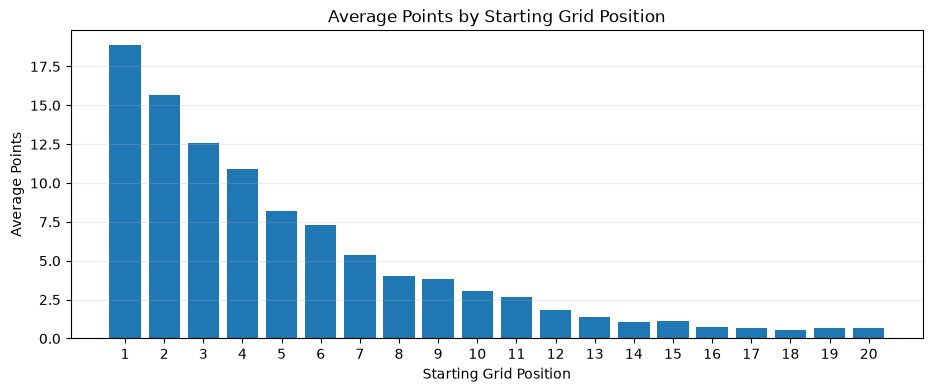

In [19]:
grid_analysis = (
    race_results.loc[
        race_results["grid"].between(1, 20)
    ]
    .groupby("grid")
    .agg(
        avg_points=("points", "mean"),
        avg_finish=("finish_position_order", "mean"),
        observations=("resultId", "size")
    )
    .reset_index()
)

display(grid_analysis)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    grid_analysis["grid"],
    grid_analysis["avg_points"]
)
ax.set_title("Average Points by Starting Grid Position")
ax.set_xlabel("Starting Grid Position")
ax.set_ylabel("Average Points")
ax.set_xticks(range(1, 21))
ax.grid(axis="y", alpha=0.25)
plt.show()

## 17. EDA — Paper Reliability vs Finish Rate

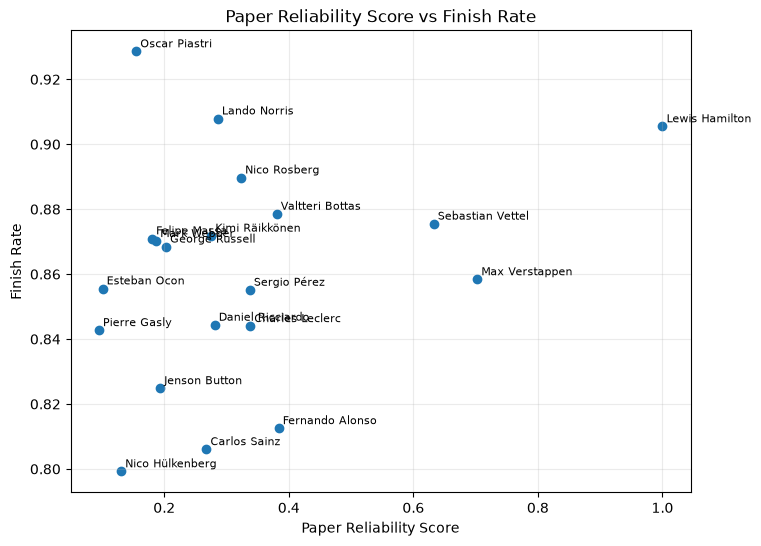

In [20]:
rel_view = (
    driver_summary.loc[
        driver_summary["starts"] >= 40
    ]
    .sort_values(
        "cumulative_points",
        ascending=False
    )
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    rel_view["paper_reliability_score"],
    rel_view["finish_rate"]
)

for _, row in rel_view.iterrows():
    ax.annotate(
        row["driver_name"],
        (
            row["paper_reliability_score"],
            row["finish_rate"]
        ),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.set_title("Paper Reliability Score vs Finish Rate")
ax.set_xlabel("Paper Reliability Score")
ax.set_ylabel("Finish Rate")
ax.grid(alpha=0.25)
plt.show()

## 18. Export Clean CSV

In [21]:
exports = {
    "race_results_clean_2010_2025.csv": race_results,
    "driver_summary_2010_2025.csv": driver_summary,
    "constructor_summary_2010_2025.csv": constructor_summary,
    "driver_constructor_summary_2010_2025.csv": driver_constructor_summary,
    "reliability_summary_2010_2025.csv": reliability_summary,
    "circuits_clean.csv": circuits_dim,
}

if qualifying_clean is not None:
    exports["qualifying_clean_2010_2025.csv"] = qualifying_clean

if pit_stops_clean is not None:
    exports["pit_stops_clean_2010_2025.csv"] = pit_stops_clean

if lap_times_clean is not None:
    exports["lap_times_clean_2010_2025.csv"] = lap_times_clean

for filename, df in exports.items():
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path} | shape={df.shape}")

Saved: /home/user/projects/avd-uts/outputs/race_results_clean_2010_2025.csv | shape=(6915, 44)
Saved: /home/user/projects/avd-uts/outputs/driver_summary_2010_2025.csv | shape=(83, 20)
Saved: /home/user/projects/avd-uts/outputs/constructor_summary_2010_2025.csv | shape=(23, 20)
Saved: /home/user/projects/avd-uts/outputs/driver_constructor_summary_2010_2025.csv | shape=(380, 18)
Saved: /home/user/projects/avd-uts/outputs/reliability_summary_2010_2025.csv | shape=(106, 8)
Saved: /home/user/projects/avd-uts/outputs/circuits_clean.csv | shape=(78, 9)
Saved: /home/user/projects/avd-uts/outputs/qualifying_clean_2010_2025.csv | shape=(6891, 18)
Saved: /home/user/projects/avd-uts/outputs/pit_stops_clean_2010_2025.csv | shape=(12784, 16)
Saved: /home/user/projects/avd-uts/outputs/lap_times_clean_2010_2025.csv | shape=(369465, 15)


## 19. Final Validation

In [22]:
validation_rows = []

for filename, df in exports.items():
    validation_rows.append({
        "file": filename,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicates": int(df.duplicated().sum()),
        "missing_pct": round(
            df.isna().mean().mean() * 100,
            2
        ),
        "min_season": (
            df["season"].min()
            if "season" in df.columns
            else np.nan
        ),
        "max_season": (
            df["season"].max()
            if "season" in df.columns
            else np.nan
        ),
    })

validation = pd.DataFrame(validation_rows)
display(validation)

assert race_results["season"].min() >= START_YEAR
assert race_results["season"].max() <= END_YEAR
assert race_results["resultId"].duplicated().sum() == 0

print("Validation passed.")
print("All outputs:", OUTPUT_DIR)

,file,rows,columns,duplicates,missing_pct,min_season,max_season
0,race_results_clean_2010_2025.csv,6915,44,0,3.24,2010.0,2025.0
1,driver_summary_2010_2025.csv,83,20,0,0.00,NaN,NaN
2,constructor_summary_2010_2025.csv,23,20,0,0.00,NaN,NaN
3,driver_constructor_summary_2010_2025.csv,380,18,0,0.00,2010.0,2025.0
4,reliability_summary_2010_2025.csv,106,8,0,0.00,NaN,NaN
5,circuits_clean.csv,78,9,0,0.00,NaN,NaN
6,qualifying_clean_2010_2025.csv,6891,18,0,5.15,2010.0,2025.0
7,pit_stops_clean_2010_2025.csv,12784,16,0,0.68,2010.0,2025.0
8,lap_times_clean_2010_2025.csv,369465,15,0,0.67,2010.0,2025.0


Validation passed.
All outputs: /home/user/projects/avd-uts/outputs
